In [1]:
import arviz as az
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from jax.scipy.special import gammaln, logsumexp
from numpyro.infer import NUTS, MCMC, Predictive, SVI
import jax.scipy.special as jsp
import jax.scipy.stats as jsstats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib_fontja
from jax.scipy.special import log_ndtr

from numpyro.infer import SVI, Trace_ELBO, TraceGraph_ELBO
from numpyro.infer.autoguide import AutoDelta, AutoMultivariateNormal, AutoBNAFNormal# AutoBNAFNormal

In [2]:
def nb2_logsf_normal(cap_t, mu_t, alpha):
    var_t = mu_t + (mu_t**2) / alpha
    sigma_t = jnp.sqrt(var_t)
    return jsstats.norm.logsf(cap_t - 0.5, loc=mu_t, scale=sigma_t)

In [3]:
def nb2_logsf_normal(cap, mu, alpha):
    """
    Censoring log survival for NB2 via Normal approximation (with continuity correction).
    Uses: log P(Y >= cap) ≈ log P(N(mu, sigma^2) >= cap - 0.5)
    """
    mu = _safe_pos(mu, 1e-9)
    alpha = _safe_pos(alpha, 1e-9)
    var = mu + (mu**2) / alpha
    sigma = jnp.sqrt(jnp.maximum(var, 1e-12))
    z = (mu - (cap - 0.5)) / sigma
    return log_ndtr(z)

In [4]:
def _as_industry_thresholds(x, num_industries, dtype):
    """
    x:
      - scalar: 共通閾値として (num_industries, 1) にブロードキャスト
      - (num_industries,) or list length=num_industries: 業種別閾値
      - (num_industries,1): そのまま
    """
    arr = jnp.asarray(x, dtype=dtype)
    if arr.ndim == 0:
        return jnp.full((num_industries, 1), arr, dtype=dtype)
    if arr.ndim == 1 and arr.shape[0] == num_industries:
        return arr.reshape(num_industries, 1)
    if arr.ndim == 2 and arr.shape == (num_industries, 1):
        return arr
    raise ValueError(f"boost_period must be scalar or shape ({num_industries},) or ({num_industries},1). Got {arr.shape}.")

def _safe_pos(x, eps=1e-9):
    return jnp.maximum(x, eps)

def _softcap_flow(flow, available):
    """Ensure flow does not exceed available stock (and is non-negative)."""
    return jnp.clip(flow, a_min=0.0, a_max=jnp.maximum(available, 0.0))


def nb2_logsf_normal(cap, mu, alpha):
    """
    Censoring log survival for NB2 via Normal approximation (with continuity correction).
    Uses: log P(Y >= cap) ≈ log P(N(mu, sigma^2) >= cap - 0.5)
    """
    mu = _safe_pos(mu, 1e-9)
    alpha = _safe_pos(alpha, 1e-9)
    var = mu + (mu**2) / alpha
    sigma = jnp.sqrt(jnp.maximum(var, 1e-12))
    z = (mu - (cap - 0.5)) / sigma
    return log_ndtr(z)

# -----------------------------
# Stable Coupled Bass + Migration Bass
#   - Prior tightening on weakly-identified parameters
#   - Non-centered parameterizations for log-scales
#   - Scale-identification guards (rho capped, season mean-1, flow caps, positivity)
# -----------------------------
def coupled_bass_with_migration_stable(
    t_values,            # (T,)
    season_indices,      # (T,) integer 0..season_dim-1
    inventory_cap,       # (T,2)
    sales_data=None,     # (T,2)
    season_dim=12,
    K=5,
    **params,
):
    """
    2-industry expanded Bass with migration flows also modeled as Bass processes.

    Key stabilizers:
      1) Hierarchical + non-centered priors on log M, log p, log q (organic) and (migration)
      2) rho_ij := rho_max * sigmoid(logit_rho_ij) to keep migration market potential bounded
      3) Season factors exp(centered) normalized to mean=1 per industry (scale guard)
      4) Flow caps: migration outflow <= current stock; stocks clipped >=0
      5) Positive guards on intensities / denominators
    """
    num_industries = 2
    T = int(len(t_values))
    t_values = jnp.asarray(t_values)
    season_idx = jnp.asarray(season_indices).astype(jnp.int32)

    # -------------------------
    # Hyperpriors (tighten / override via params)
    # -------------------------
    # Organic: log M, log p, log q
    logM_mu0    = params.get("logM_mu0", 10.0)        # adjust to your scale
    logM_sd0    = params.get("logM_sd0", 2.0)
    logM_sd_h0  = params.get("logM_sd_h0", 0.5)

    logp_mu0    = params.get("logp_mu0", -6.0)
    logp_sd0    = params.get("logp_sd0", 1.0)
    logp_sd_h0  = params.get("logp_sd_h0", 0.5)

    logq_mu0    = params.get("logq_mu0", -4.0)
    logq_sd0    = params.get("logq_sd0", 1.0)
    logq_sd_h0  = params.get("logq_sd_h0", 0.5)

    # Migration: log p_ij, log q_ij (typically smaller / more regularized)
    mig_logp_mu0   = params.get("mig_logp_mu0", -7.0)
    mig_logp_sd0   = params.get("mig_logp_sd0", 0.8)
    mig_logp_sd_h0 = params.get("mig_logp_sd_h0", 0.4)

    mig_logq_mu0   = params.get("mig_logq_mu0", -5.0)
    mig_logq_sd0   = params.get("mig_logq_sd0", 0.8)
    mig_logq_sd_h0 = params.get("mig_logq_sd_h0", 0.4)

    # rho (migration market fraction) guard
    rho_max = params.get("rho_max", 0.30)  # cap migration potential to <= 30% of source market
    # Center logit so prior mean ~ small fraction (e.g., 0.05*rho_max)
    rho_mean_frac = params.get("rho_mean_frac", 0.20)  # fraction of rho_max, mean = rho_mean_frac*rho_max
    rho_mean = float(rho_mean_frac)
    rho_logit_mu0 = params.get("rho_logit_mu0", jnp.log(rho_mean / (1.0 - rho_mean)))
    rho_logit_sd0 = params.get("rho_logit_sd0", 0.8)

    # Seasonality regularization
    fourier_decay = params.get("fourier_decay", 1.0)
    season_amp_scale_global = params.get("season_amp_scale_global", 0.5)  # global shrink
    season_amp_scale_ind    = params.get("season_amp_scale_ind", 0.5)     # industry dev shrink

    # Boost regularization
    boost_mu   = params.get("boost_mu", -10.0)
    boost_sd   = params.get("boost_scale", 1.0)

    # Overdispersion alpha prior (often weakly identified with censoring; keep informative)
    alpha_rate = params.get("alpha_var", 1.0)  # Exponential(rate)

    # -------------------------
    # 1) Organic parameters (hierarchical + non-centered)
    # -------------------------
    # Shared hyperparameters
    logM_mu = numpyro.sample("logM_mu", dist.Normal(logM_mu0, logM_sd0))
    logM_sd = numpyro.sample("logM_sd", dist.HalfNormal(logM_sd_h0))

    logp_mu = numpyro.sample("logp_mu", dist.Normal(logp_mu0, logp_sd0))
    logp_sd = numpyro.sample("logp_sd", dist.HalfNormal(logp_sd_h0))

    logq_mu = numpyro.sample("logq_mu", dist.Normal(logq_mu0, logq_sd0))
    logq_sd = numpyro.sample("logq_sd", dist.HalfNormal(logq_sd_h0))

    season_amp_g = numpyro.sample("season_amp_global", dist.HalfNormal(season_amp_scale_global))
    with numpyro.plate("industries", num_industries):
        # non-centered per-industry eps
        eps_M  = numpyro.sample("eps_logM", dist.Normal(0.0, 1.0))
        eps_p  = numpyro.sample("eps_logp", dist.Normal(0.0, 1.0))
        eps_q  = numpyro.sample("eps_logq", dist.Normal(0.0, 1.0))

        logM_i = numpyro.deterministic("logM", logM_mu + logM_sd * eps_M)
        logp_i = numpyro.deterministic("log_p", logp_mu + logp_sd * eps_p)
        logq_i = numpyro.deterministic("log_q", logq_mu + logq_sd * eps_q)

        M      = numpyro.deterministic("M", _safe_pos(jnp.exp(logM_i), 1e-6))
        p_base = numpyro.deterministic("p_base", _safe_pos(jnp.exp(logp_i), 1e-12))
        q_org  = numpyro.deterministic("q_org", _safe_pos(jnp.exp(logq_i), 1e-12))

        # Overdispersion per industry (informative; adjust if you have strong evidence otherwise)
        alpha = numpyro.sample("alpha", dist.Exponential(alpha_rate))

        # Boost strength (log-scale) per industry
        log_boost = numpyro.sample("log_boost_strength", dist.Normal(boost_mu, boost_sd))
        boost_strength = numpyro.deterministic("boost_strength", jnp.exp(log_boost))

        # Season amplitude (hierarchical shrinkage)
        # global + industry deviation (both half-normal); keeps amplitude from exploding
#        season_amp_g = numpyro.sample("season_amp_global", dist.HalfNormal(season_amp_scale_global))
        season_amp_i = numpyro.sample("season_amp_ind", dist.HalfNormal(season_amp_scale_ind))
        season_amp = numpyro.deterministic("season_amp", season_amp_g * season_amp_i)  # (2,)
    
        # ★重要：K は event 次元にする（sample_shape は使わない）
        a_raw = numpyro.sample(
            "fourier_a_raw",
            dist.Normal(0.0, 1.0).expand((K,)).to_event(1)
        )  # (2, K)
    
        b_raw = numpyro.sample(
            "fourier_b_raw",
            dist.Normal(0.0, 1.0).expand((K,)).to_event(1)
        )  # (2, K)
        
#        season_amp_i = numpyro.sample("season_amp_ind", dist.HalfNormal(season_amp_scale_ind))
#        season_amp = numpyro.deterministic("season_amp", season_amp_g * season_amp_i)

        # Fourier coefficients: already non-centered via raw ~ N(0,1) then scaled
#        a_raw = numpyro.sample("fourier_a_raw", dist.Normal(0.0, 1.0), sample_shape=(K,))
#        b_raw = numpyro.sample("fourier_b_raw", dist.Normal(0.0, 1.0), sample_shape=(K,))

    # -------------------------
    # 2) Build seasonal factors (mean-1 normalization) per industry
    # -------------------------
    k_idx = jnp.arange(1, K + 1, dtype=t_values.dtype)  # (K,)
    scale_k = 1.0 / (k_idx ** fourier_decay)            # (K,)

    a = season_amp[:, None] * a_raw * scale_k           # (2,K)
    b = season_amp[:, None] * b_raw * scale_k

    m_grid = jnp.arange(season_dim, dtype=t_values.dtype)
    angs = 2.0 * jnp.pi * jnp.outer(m_grid, k_idx) / season_dim  # (S,K)

    raw = jnp.einsum("ik,tk->it", a, jnp.cos(angs)) + jnp.einsum("ik,tk->it", b, jnp.sin(angs))  # (2,S)
    raw_centered = raw - jnp.mean(raw, axis=1, keepdims=True)
    season_factors = jnp.exp(raw_centered)
    season_factors = season_factors / jnp.mean(season_factors, axis=1, keepdims=True)
    numpyro.deterministic("season_factors", season_factors)  # (2,S)

    # -------------------------
    # 3) Time-varying p(t) with boost (guarded)
    # -------------------------
    boost_period = params.get("boost_period", 0)  # デフォルトは boost なし
    boost_thresholds = _as_industry_thresholds(boost_period, num_industries, t_values.dtype)  # (2,1)
    
    is_boost = (t_values[None, :] < boost_thresholds).astype(jnp.float32)  # (2,T)
    p_t = numpyro.deterministic(
        "p_t",
        _safe_pos(p_base[:, None] + boost_strength[:, None] * is_boost, 1e-12)
    )

#    boost_thresholds = jnp.array(params.get("boost_period", [0, 0]), dtype=t_values.dtype).reshape(num_industries, 1)
#    is_boost = (t_values[None, :] < boost_thresholds).astype(jnp.float32)     # (2,T)
#    p_t = numpyro.deterministic("p_t", _safe_pos(p_base[:, None] + boost_strength[:, None] * is_boost, 1e-12))

    # -------------------------
    # 4) Migration parameters (hierarchical + non-centered) + rho caps
    # -------------------------
    # Migration hyperpriors
    mig_logp_mu = numpyro.sample("mig_logp_mu", dist.Normal(mig_logp_mu0, mig_logp_sd0))
    mig_logp_sd = numpyro.sample("mig_logp_sd", dist.HalfNormal(mig_logp_sd_h0))

    mig_logq_mu = numpyro.sample("mig_logq_mu", dist.Normal(mig_logq_mu0, mig_logq_sd0))
    mig_logq_sd = numpyro.sample("mig_logq_sd", dist.HalfNormal(mig_logq_sd_h0))

    # Two directed flows: 0->1 and 1->0
    eps_p01 = numpyro.sample("eps_mig_logp_01", dist.Normal(0.0, 1.0))
    eps_q01 = numpyro.sample("eps_mig_logq_01", dist.Normal(0.0, 1.0))
    eps_p10 = numpyro.sample("eps_mig_logp_10", dist.Normal(0.0, 1.0))
    eps_q10 = numpyro.sample("eps_mig_logq_10", dist.Normal(0.0, 1.0))

    log_p_01 = numpyro.deterministic("log_p_01", mig_logp_mu + mig_logp_sd * eps_p01)
    log_q_01 = numpyro.deterministic("log_q_01", mig_logq_mu + mig_logq_sd * eps_q01)
    log_p_10 = numpyro.deterministic("log_p_10", mig_logp_mu + mig_logp_sd * eps_p10)
    log_q_10 = numpyro.deterministic("log_q_10", mig_logq_mu + mig_logq_sd * eps_q10)

    p_01 = _safe_pos(jnp.exp(log_p_01), 1e-12)
    q_01 = _safe_pos(jnp.exp(log_q_01), 1e-12)
    p_10 = _safe_pos(jnp.exp(log_p_10), 1e-12)
    q_10 = _safe_pos(jnp.exp(log_q_10), 1e-12)

    # rho_ij = rho_max * sigmoid(logit_rho_ij)
    logit_rho_01 = numpyro.sample("logit_rho_01", dist.Normal(rho_logit_mu0, rho_logit_sd0))
    logit_rho_10 = numpyro.sample("logit_rho_10", dist.Normal(rho_logit_mu0, rho_logit_sd0))
    rho_01 = numpyro.deterministic("rho_01", rho_max * jax.nn.sigmoid(logit_rho_01))
    rho_10 = numpyro.deterministic("rho_10", rho_max * jax.nn.sigmoid(logit_rho_10))

    # Migration market potentials tied to source markets (scale identification)
    M_01 = numpyro.deterministic("M_01", _safe_pos(rho_01 * M[0], 1e-9))
    M_10 = numpyro.deterministic("M_10", _safe_pos(rho_10 * M[1], 1e-9))

    # -------------------------
    # 5) State evolution via scan
    #   carry = (N (2,), C (2,): [C_01, C_10])
    # -------------------------
    def transition_fn(carry, t_idx):
        N = carry[0]  # (2,)
        C = carry[1]  # (2,)

        # Season index (tracer-safe)
        s_i = jax.lax.dynamic_index_in_dim(season_idx, t_idx, axis=0, keepdims=False)
        sN = season_factors[:, s_i]  # (2,)

        # ---- Organic adoption ----
        remaining = jnp.maximum(M - N, 0.0)
        rate_org = p_t[:, t_idx] + q_org * (N / _safe_pos(M, 1e-9))
        lam_org = jnp.maximum(sN * rate_org, 0.0)
        new_org = remaining * (1.0 - jnp.exp(-lam_org))  # (2,)

        # ---- Migration Bass flows ----
        C_01, C_10 = C[0], C[1]

        # 0->1
        rem_01 = jnp.maximum(M_01 - C_01, 0.0)
        rate_01 = p_01 + q_01 * (C_01 / _safe_pos(M_01, 1e-9))
        lam_01 = jnp.maximum(season_factors[0, s_i] * rate_01, 0.0)
        mig_01_raw = rem_01 * (1.0 - jnp.exp(-lam_01))
        mig_01 = _softcap_flow(mig_01_raw, N[0])

        # 1->0
        rem_10 = jnp.maximum(M_10 - C_10, 0.0)
        rate_10 = p_10 + q_10 * (C_10 / _safe_pos(M_10, 1e-9))
        lam_10 = jnp.maximum(season_factors[1, s_i] * rate_10, 0.0)
        mig_10_raw = rem_10 * (1.0 - jnp.exp(-lam_10))
        mig_10 = _softcap_flow(mig_10_raw, N[1])

        # Update cumulative migrants (monotone, bounded by M_ij implicitly)
        C_next = jnp.stack([C_01 + mig_01, C_10 + mig_10])

        # Update stocks (guard >=0)
        N0_next = N[0] + new_org[0] + mig_10 - mig_01
        N1_next = N[1] + new_org[1] + mig_01 - mig_10
        N_next = jnp.maximum(jnp.stack([N0_next, N1_next]), 0.0)

        # Observed sales = gross adds = organic + inflow
        sales = jnp.stack([new_org[0] + mig_10, new_org[1] + mig_01])

        return (N_next, C_next), sales

#    init_N = jnp.zeros((num_industries,), dtype=t_values.dtype)
#    init_C = jnp.zeros((2,), dtype=t_values.dtype)
#    time_idx = jnp.arange(T, dtype=jnp.int32)

    state_dtype = jnp.result_type(t_values, jnp.float32)
    
    init_N = jnp.zeros((num_industries,), dtype=state_dtype)  # float
    init_C = jnp.zeros((2,), dtype=state_dtype)               # float
    time_idx = jnp.arange(T, dtype=jnp.int32)
    
    (_, _), pred_sales = jax.lax.scan(transition_fn, (init_N, init_C), time_idx)

#    (_, _), pred_sales = jax.lax.scan(transition_fn, (init_N, init_C), time_idx)  # (T,2)
    mu_t = numpyro.deterministic("demand_pred", _safe_pos(pred_sales, 1e-9))

    # -------------------------
    # 6) Likelihood: NB2 + censoring (industry-specific alpha)
    # -------------------------

    if sales_data is not None:
        y = jnp.asarray(sales_data).astype(jnp.int32)  # (T,2)
        cap_in = jnp.asarray(inventory_cap).astype(jnp.int32)
    
        # cap は「総量」用に (T,) にする
        # - cap_in が (T,) ならそのまま
        # - cap_in が (T,2) なら（同一capを複製している想定で）max を取って (T,) に落とす
        cap_total = cap_in if cap_in.ndim == 1 else cap_in.max(axis=1)  # (T,)
    
        # 業種別 NB2（独立）: mean (T,2), alpha (1,2) -> broadcast
        nb = dist.NegativeBinomial2(mean=mu_t, concentration=_safe_pos(alpha[None, :], 1e-9))
    
        # --- 非打ち切り時（総量がcap未満）：通常尤度（業種別 log_prob の和）---
        logp_uncens_t = jnp.sum(nb.log_prob(y), axis=1)  # (T,)
    
        # --- 打ち切り判定は「総量」で ---
        y_total = jnp.sum(y, axis=1)  # (T,)
        is_cens_total = y_total >= cap_total  # (T,)
    
        # --- 打ち切り時：log P(Y_total >= cap_total) を正規近似で ---
        # NB2 の分散: var = mu + mu^2/alpha
        var_t = mu_t + (mu_t**2) / _safe_pos(alpha[None, :], 1e-9)   # (T,2)
        mu_total = jnp.sum(mu_t, axis=1)                              # (T,)
        var_total = jnp.sum(var_t, axis=1)                            # (T,)
        sigma_total = jnp.sqrt(jnp.maximum(var_total, 1e-12))         # (T,)
    
        # continuity correction: cap_total - 0.5
        z = (mu_total - (cap_total - 0.5)) / sigma_total
        logp_cens_t = log_ndtr(z)  # (T,)
    
        # 時点ごとの対数尤度（総量打ち切り）
        ll_t = jnp.where(is_cens_total, logp_cens_t, logp_uncens_t)  # (T,)
    
        numpyro.deterministic("log_likelihood", ll_t)
        numpyro.factor("obs_loglik", jnp.sum(ll_t))

In [5]:
def meta_model(t_values, season_indices, inventory_cap, sales_data, **init_params):
    """
    Coupled Bass Model 用のメタモデル（ハイパーパラメータ学習用ラッパー）。
    init_params で与えられた初期値を起点に、NumPyroのparam（最適化変数）を定義し、
    モデル本体 (coupled_bass_with_migration_stable) に渡します。
    """
    
    # --- 1. Organic Parameters (自律成長パラメータ) ---
    
    # M (市場規模): 学習させず、初期値を固定 (Fixed)
    # ユーザーコードの意図通り、Mは学習から除外
    
    # p (Innovation): 平均とスケールを学習
    logp_mu_opt = numpyro.param("logp_mu_opt", init_params["logp_mu0"])
    logp_sd_opt = numpyro.param("logp_sd_opt", init_params["logp_sd0"], constraint=dist.constraints.positive)
    
    # q (Imitation): 平均とスケールを学習
    logq_mu_opt = numpyro.param("logq_mu_opt", init_params["logq_mu0"])
    logq_sd_opt = numpyro.param("logq_sd_opt", init_params["logq_sd0"], constraint=dist.constraints.positive)

    # --- 2. Migration Parameters (移動パラメータ) [新規追加] ---
    
    # Migration p: 学習
    mig_logp_mu_opt = numpyro.param("mig_logp_mu_opt", init_params["mig_logp_mu0"])
    mig_logp_sd_opt = numpyro.param("mig_logp_sd_opt", init_params["mig_logp_sd0"], constraint=dist.constraints.positive)

    # Migration q: 学習
    mig_logq_mu_opt = numpyro.param("mig_logq_mu_opt", init_params["mig_logq_mu0"])
    mig_logq_sd_opt = numpyro.param("mig_logq_sd_opt", init_params["mig_logq_sd0"], constraint=dist.constraints.positive)

    # --- 3. Other Hyperparameters ---
    
    # Seasonality (Global Scale): 学習
    season_scale_opt = numpyro.param("season_amp_scale_opt", init_params["season_amp_scale_global"], constraint=dist.constraints.positive)
    
    # Boost (広告効果): 学習
    boost_mu_opt = numpyro.param("boost_mu_opt", init_params["boost_mu"])
    boost_scale_opt = numpyro.param("boost_scale_opt", init_params["boost_scale"], constraint=dist.constraints.positive)
    
    # Alpha (分散パラメータ): 学習
    alpha_rate_opt = numpyro.param("alpha_var_opt", init_params["alpha_var"], constraint=dist.constraints.positive)

    # --- 4. パラメータ辞書の構築 ---
    # モデル本体の引数名 (xxx_mu0, xxx_sd0 等) にマッピング
    learned_params = {
        # Fixed (学習なし)
        "logM_mu0": init_params["logM_mu0"],
        "logM_sd0": init_params["logM_sd0"],
        "boost_period": init_params["boost_period"],
        "rho_max": init_params.get("rho_max", 0.3),
        
        # Optimized (学習あり)
        "logp_mu0": logp_mu_opt,
        "logp_sd0": logp_sd_opt,
        
        "logq_mu0": logq_mu_opt,
        "logq_sd0": logq_sd_opt,
        
        "mig_logp_mu0": mig_logp_mu_opt,
        "mig_logp_sd0": mig_logp_sd_opt,
        "mig_logq_mu0": mig_logq_mu_opt,
        "mig_logq_sd0": mig_logq_sd_opt,
        
        "season_amp_scale_global": season_scale_opt,
        "boost_mu": boost_mu_opt,
        "boost_scale": boost_scale_opt,
        "alpha_var": alpha_rate_opt,
    }

    # モデル本体を呼び出し
    coupled_bass_with_migration_stable(
        t_values, 
        season_indices, 
        inventory_cap, 
        sales_data, 
        **learned_params
    )

# --- 初期値 (Prior Params) の設定 ---
# coupled_bass_with_migration_stable の変数名に合わせた辞書

prior_params = {
    # Organic Growth (M, p, q)
    "logM_mu0": jnp.log(5_000), 
    "logM_sd0": 0.5,           # var=0.5 -> sd ≈ 0.7 or just set sd=1.0 for safety
    
    "logp_mu0": jnp.log(0.01),
    "logp_sd0": 0.3,           # var=0.3 -> sd ≈ 0.55
    
    "logq_mu0": jnp.log(0.25),
    "logq_sd0": 0.5,           # var=0.5 -> sd ≈ 0.7
    
    # Migration Growth (New)
    "mig_logp_mu0": jnp.log(0.001), # 移動の自然発生は少ないと仮定
    "mig_logp_sd0": 0.25,
    "mig_logq_mu0": jnp.log(0.05),  # 移動の模倣効果
    "mig_logq_sd0": 0.25,
    
    # Others
    "alpha_var": 0.5,          # rate parameter for Exponential
    "season_amp_scale_global": 0.5,
    
    "boost_period": 6,
    "boost_mu": jnp.log(0.03),
    "boost_scale": 0.5,
    
    # Fixed constraints
    "rho_max": 0.3
}

In [6]:
df = pd.read_csv("data/20251227coolrevolution実績.csv", 
                 parse_dates=["受注_伝票登録日付"],
                 encoding='utf-8-sig')

# 列名をわかりやすくリネーム
df = df.rename(columns={
    "受注_伝票登録日付": "date",
    "売上金額": "sales"
})
df["day"] = df.date.dt.date
df["is_lease"] = (df["業種"] == "リース レンタル") * 1

sales_ = df.groupby(by=["is_lease", pd.Grouper(key='date', freq='MS')]).sales.size()
sales = dict()
sales["not_lease"] = sales_.loc[0]
sales["lease"] = sales_.loc[1]
sales = pd.DataFrame(sales).fillna(0)

inventory_cap = pd.read_csv("data/クーレボ在庫.csv")
inventory_cap.yyyymm = inventory_cap.yyyymm.map(lambda x: pd.to_datetime(str(x)+"01"))
inventory_cap = inventory_cap.rename(columns={"yyyymm": "date", '在庫数（月末時点）': 'inventory'})
inventory_cap = inventory_cap.set_index('date')["inventory"]

sales_ = df.groupby(pd.Grouper(key='date', freq='MS')).sales.size()
data = pd.DataFrame({"sales": sales_, "inventory": inventory_cap}).dropna(axis=0, how='any')
data['month'] = data.index.month
data['inventory_cap'] = data[['inventory', 'sales']].max(axis=1)
data = data.fillna(0)
data = data.loc[sales.index]
data = data.reset_index()


t_values = data.index
inv_cap = data['inventory_cap']
season_indices = data['month'] - 1
# sales = data['sales']

In [7]:
predictive = Predictive(coupled_bass_with_migration_stable, num_samples=1000)
rng_key = jax.random.PRNGKey(42)
prior_samples = predictive(
    rng_key, 
    t_values=t_values.values, 
    season_indices=season_indices.values, 
    inventory_cap=inv_cap.values,
    sales_data=None, 
    **prior_params
)

In [8]:
optimizer = numpyro.optim.Adam(step_size=1e-4)
guide = AutoMultivariateNormal(meta_model)
svi = SVI(meta_model, guide, optimizer, loss=Trace_ELBO())

# svi = SVI(meta_model, guide, optimizer, loss=Trace_ELBO())

# 3. 実行（ハイパーパラメータの最適化）
svi_result = svi.run(
    jax.random.PRNGKey(0), 5000, 
    t_values=t_values.values, 
    season_indices=season_indices.values, 
    inventory_cap=inv_cap.values, 
    sales_data=sales.values,
    **prior_params
)

params = dict()
for k, v in prior_params.items():
    try:
        params[k] = svi_result.params[f"{k}_opt"]
    except:
        params[k] = prior_params[k]
        pass

display(params)

100%|█| 5000/5000 [00:02<00:00, 1846.76it/s, init loss: 207937486848.0000, avg. 


{'logM_mu0': Array(8.517193, dtype=float32, weak_type=True),
 'logM_sd0': 0.5,
 'logp_mu0': Array(-4.6051702, dtype=float32, weak_type=True),
 'logp_sd0': 0.3,
 'logq_mu0': Array(-1.3862944, dtype=float32, weak_type=True),
 'logq_sd0': 0.5,
 'mig_logp_mu0': Array(-6.9077554, dtype=float32, weak_type=True),
 'mig_logp_sd0': 0.25,
 'mig_logq_mu0': Array(-2.9957323, dtype=float32, weak_type=True),
 'mig_logq_sd0': 0.25,
 'alpha_var': Array(0.82327145, dtype=float32),
 'season_amp_scale_global': 0.5,
 'boost_period': 6,
 'boost_mu': Array(-3.0748932, dtype=float32),
 'boost_scale': Array(0.7609235, dtype=float32),
 'rho_max': 0.3}

In [14]:
posterior = Predictive(
    coupled_bass_with_migration_stable,
    guide=guide,
    params=svi_result.params,
    num_samples=10,
    return_sites=None  # すべて返す（必要なら site 名で絞る）
)(
    jax.random.PRNGKey(1),
    t_values=t_values.values,
    season_indices=season_indices.values,
    inventory_cap=inv_cap.values,
    sales_data=None,  # 事後サンプルだけなら None
    **params          # ← ここが重要：最適化済みハイパーパラメータを渡す
)

<Axes: >

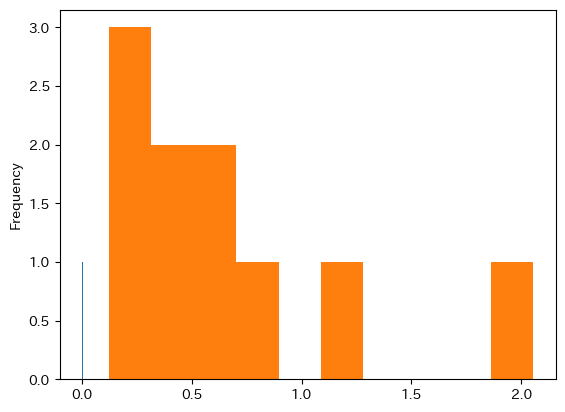

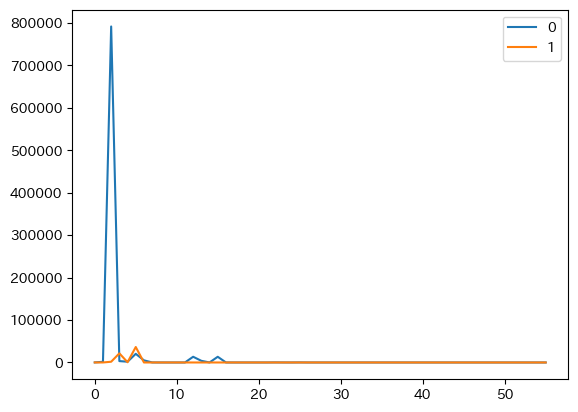

In [15]:
# pd.DataFrame(M01)
pd.Series(posterior["M_01"]).median()
pd.Series(posterior["M_10"]).median()
pd.DataFrame(posterior["M"]).median()

pd.Series(np.exp(posterior["log_p"][:, 0])).plot(kind='hist')
pd.Series(np.exp(posterior["log_p"][:, 1])).plot(kind='hist')
# pd.Series(np.exp(posterior["log_q"])).plot(kind='hist')

pd.DataFrame(posterior["demand_pred"].mean(axis=0)).plot()

In [11]:
"""
seed_mcmc = 125
nuts = NUTS(coupled_bass_with_migration_stable, dense_mass=True)
mcmc = MCMC(nuts, num_warmup=1000, num_samples=10000, num_chains=1, progress_bar=True)

mcmc.run(
    jax.random.PRNGKey(seed_mcmc),
    t_values.values,
    season_indices.values,
    inv_cap.values,
    sales.values,
    season_dim=12,
    **params
)
"""

'\nseed_mcmc = 125\nnuts = NUTS(coupled_bass_with_migration_stable, dense_mass=True)\nmcmc = MCMC(nuts, num_warmup=1000, num_samples=10000, num_chains=1, progress_bar=True)\n\nmcmc.run(\n    jax.random.PRNGKey(seed_mcmc),\n    t_values.values,\n    season_indices.values,\n    inv_cap.values,\n    sales.values,\n    season_dim=12,\n    **params\n)\n'

In [12]:
# df = pd.read_csv("data/20251227coolrevolution実績.csv", 
#                  parse_dates=["受注_伝票登録日付"],
#                  encoding='utf-8-sig')

In [13]:
# 将来の予測